# Exercise 1 – Real-Estate Properties Not Sold for More Than Six Months

Maggie wants to understand why some properties have remained unsold for more than six months.

**Note:** The question does not provide a dataset. Therefore, this notebook uses a small **illustrative dataset** to demonstrate the analysis. It should not be presented as real company data.


In [1]:
#ch.sc.u4cse24145
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "Property": ["P1","P2","P3","P4","P5","P6","P7","P8","P9","P10","P11","P12"],
    "Price_Lakh": [85, 120, 95, 150, 70, 135, 110, 90, 160, 75, 125, 100],
    "Area_sqft": [1100, 1450, 1200, 1800, 950, 1600, 1300, 1050, 1900, 900, 1500, 1250],
    "Age_Years": [8, 15, 5, 20, 3, 18, 10, 6, 22, 4, 12, 7],
    "Days_On_Market": [210, 245, 190, 280, 75, 230, 200, 65, 300, 90, 215, 185],
    "Distance_City_km": [12, 18, 8, 25, 5, 20, 15, 7, 28, 6, 17, 10],
    "Condition_Score": [7, 6, 8, 5, 9, 6, 7, 9, 5, 8, 6, 8]
})

data["Unsold_6_Months"] = data["Days_On_Market"] > 180
data


,Property,Price_Lakh,Area_sqft,Age_Years,Days_On_Market,Distance_City_km,Condition_Score,Unsold_6_Months
0,P1,85,1100,8,210,12,7,True
1,P2,120,1450,15,245,18,6,True
2,P3,95,1200,5,190,8,8,True
3,P4,150,1800,20,280,25,5,True
4,P5,70,950,3,75,5,9,False
5,P6,135,1600,18,230,20,6,True
6,P7,110,1300,10,200,15,7,True
7,P8,90,1050,6,65,7,9,False
8,P9,160,1900,22,300,28,5,True
9,P10,75,900,4,90,6,8,False


## Identify properties unsold for more than six months

In [2]:
unsold = data[data["Unsold_6_Months"]].copy()

print("Properties unsold for more than six months:")
print(unsold[["Property", "Price_Lakh", "Area_sqft", "Age_Years",
              "Days_On_Market", "Distance_City_km", "Condition_Score"]])

print("\nNumber of properties:", len(unsold))


Properties unsold for more than six months:
   Property  Price_Lakh  Area_sqft  Age_Years  Days_On_Market  \
0        P1          85       1100          8             210   
1        P2         120       1450         15             245   
2        P3          95       1200          5             190   
3        P4         150       1800         20             280   
5        P6         135       1600         18             230   
6        P7         110       1300         10             200   
8        P9         160       1900         22             300   
10      P11         125       1500         12             215   
11      P12         100       1250          7             185   

    Distance_City_km  Condition_Score  
0                 12                7  
1                 18                6  
2                  8                8  
3                 25                5  
5                 20                6  
6                 15                7  
8                 28     

## Compare long-listed properties with properties sold within six months

In [3]:
summary = data.groupby("Unsold_6_Months")[
    ["Price_Lakh", "Area_sqft", "Age_Years", "Distance_City_km", "Condition_Score"]
].mean()

summary.index = ["Sold/within 6 months", "Unsold > 6 months"]
summary


,Price_Lakh,Area_sqft,Age_Years,Distance_City_km,Condition_Score
Sold/within 6 months,78.333333,966.666667,4.333333,6.0,8.666667
Unsold > 6 months,120.000000,1455.555556,13.000000,17.0,6.444444


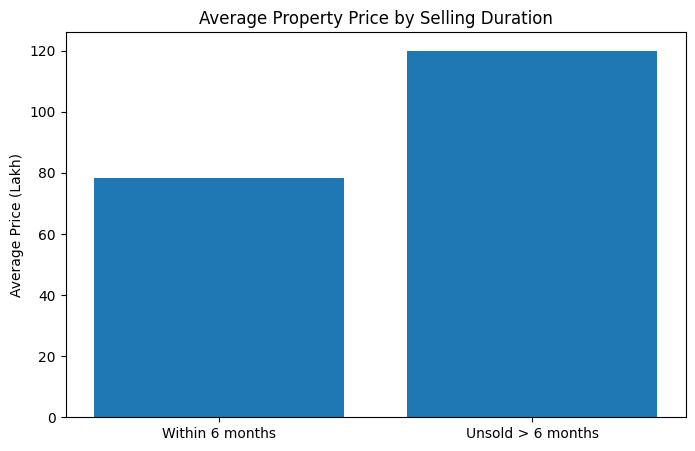

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(
    ["Within 6 months", "Unsold > 6 months"],
    [
        data.loc[~data["Unsold_6_Months"], "Price_Lakh"].mean(),
        data.loc[data["Unsold_6_Months"], "Price_Lakh"].mean()
    ]
)
plt.ylabel("Average Price (Lakh)")
plt.title("Average Property Price by Selling Duration")
plt.show()


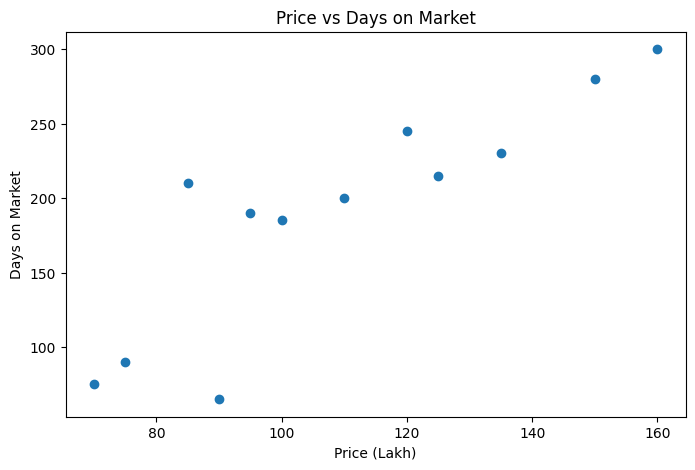

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(data["Price_Lakh"], data["Days_On_Market"])
plt.xlabel("Price (Lakh)")
plt.ylabel("Days on Market")
plt.title("Price vs Days on Market")
plt.show()


## Insights

From this **illustrative dataset**:

- Properties remaining on the market for more than six months tend to have higher average prices.
- Several long-listed properties also have greater distance from the city.
- Older properties and lower condition scores can also be examined as possible contributing factors.
- These observations are associations in this example; they do not establish that a factor causes a property not to sell.

For a real business conclusion, Maggie would need the company's actual listing data, including asking price, location, property condition, size, listing date, price changes, and sale status.
